# 07 — Task 2.4: Instruction-based LLM Prompting
Evaluates 3 prompt strategies on a **200-sample stratified subset** of the test set using the Anthropic API (Claude).

Set your API key before running:
```bash
export ANTHROPIC_API_KEY="your-key-here"
```
Or add it to a `.env` file at the project root: `ANTHROPIC_API_KEY=...`

Model used: **`claude-haiku-4-5-20251001`** — fastest and most cost-efficient Claude model.

In [1]:
import sys, os, time, re
sys.path.insert(0, '..')

import pandas as pd
from tqdm import tqdm
import anthropic

try:
    from dotenv import load_dotenv
    load_dotenv('../.env')
except ImportError:
    pass

API_KEY = os.getenv('ANTHROPIC_API_KEY', '')
if not API_KEY:
    raise EnvironmentError('Set ANTHROPIC_API_KEY in your environment or .env file')

client = anthropic.Anthropic(api_key=API_KEY)
MODEL = 'claude-haiku-4-5-20251001'
print(f'Using model: {MODEL}')

from src.utils import load_data, evaluate_predictions, save_results

Using model: claude-haiku-4-5-20251001


## 1. Sample 200 stratified test reviews

In [2]:
import random
random.seed(42)

test_texts, test_labels   = load_data('test')
train_texts, train_labels = load_data('train')

pos_idx = [i for i, l in enumerate(test_labels) if l == 'pos']
neg_idx = [i for i, l in enumerate(test_labels) if l == 'neg']

sample_idx    = random.sample(pos_idx, 100) + random.sample(neg_idx, 100)
random.shuffle(sample_idx)

sample_texts  = [test_texts[i]  for i in sample_idx]
sample_labels = [test_labels[i] for i in sample_idx]

# 3 pos + 3 neg few-shot examples from train set
few_shot_pos = [train_texts[i] for i in random.sample(
    [i for i, l in enumerate(train_labels) if l == 'pos'], 3)]
few_shot_neg = [train_texts[i] for i in random.sample(
    [i for i, l in enumerate(train_labels) if l == 'neg'], 3)]

print(f'Sample: {len(sample_texts)} reviews '
      f'({sum(l=="pos" for l in sample_labels)} pos, '
      f'{sum(l=="neg" for l in sample_labels)} neg)')

Sample: 200 reviews (100 pos, 100 neg)


## 2. Prompt definitions

In [3]:
def build_few_shot_block():
    lines = []
    for p, n in zip(few_shot_pos, few_shot_neg):
        lines.append(f'[POS] {p[:300]}')
        lines.append(f'[NEG] {n[:300]}')
    return '\n'.join(lines)

FEW_SHOT_BLOCK = build_few_shot_block()

PROMPTS = {
    'generic': lambda text: (
        'Classify the sentiment of the following text as "positive" or "negative".\n'
        'Reply with only one word.\n\n'
        f'Text: {text}'
    ),
    'domain': lambda text: (
        'You are analyzing movie reviews. Classify the sentiment of the following '
        'movie review as "positive" or "negative".\n'
        'Reply with only one word.\n\n'
        f'Review: {text}'
    ),
    'few_shot': lambda text: (
        'Classify movie review sentiment as "positive" or "negative".\n\n'
        f'Examples:\n{FEW_SHOT_BLOCK}\n\n'
        f'Now classify:\n{text}\n\n'
        'Reply with only one word: positive or negative.'
    ),
}

print('Prompts defined:', list(PROMPTS.keys()))

Prompts defined: ['generic', 'domain', 'few_shot']


## 3. Inference helper

In [4]:
def parse_label(response: str) -> str:
    r = response.strip().lower()
    if re.search(r'\bpositive\b', r):
        return 'pos'
    if re.search(r'\bnegative\b', r):
        return 'neg'
    first = r.split()[0] if r.split() else ''
    return 'pos' if first in ('pos', 'positive') else 'neg'


def run_prompt_experiment(name, prompt_fn, texts, labels,
                          delay=0.2, save_path=None):
    raw_responses, preds, errors = [], [], 0

    for text in tqdm(texts, desc=name):
        prompt = prompt_fn(text[:1500])
        try:
            response = client.messages.create(
                model=MODEL,
                max_tokens=10,
                messages=[{'role': 'user', 'content': prompt}],
            )
            answer = response.content[0].text
        except Exception as e:
            answer = ''
            errors += 1
        raw_responses.append(answer)
        preds.append(parse_label(answer))
        time.sleep(delay)

    print(f'{name}: {errors} API errors')

    if save_path:
        pd.DataFrame({'text': texts, 'true': labels,
                      'response': raw_responses, 'pred': preds}
                    ).to_csv(save_path, index=False)

    return preds, evaluate_predictions(labels, preds)

## 4. Run all 3 prompts

In [5]:
prompt_results = {}

for pname, pfn in PROMPTS.items():
    preds, metrics = run_prompt_experiment(
        name=f'Claude Haiku — {pname}',
        prompt_fn=pfn,
        texts=sample_texts,
        labels=sample_labels,
        delay=0.2,
        save_path=f'../results/llm_{pname}_responses.csv',
    )
    prompt_results[pname] = metrics
    print(f'{pname}: {metrics}')
    save_results(
        task='2.4',
        approach=f'Claude Haiku ({MODEL}) — {pname} prompt',
        metrics=metrics,
        preprocessing='200-sample stratified subset, truncated to 1500 chars',
        notes=f'Model: {MODEL}, max_tokens=10, temperature=default'
    )

Claude Haiku — generic: 100%|██████████| 200/200 [03:17<00:00,  1.01it/s]


Claude Haiku — generic: 0 API errors
generic: {'accuracy': 0.95, 'precision': 0.9412, 'recall': 0.96, 'f1': 0.9505}
Saved: [2.4] Claude Haiku (claude-haiku-4-5-20251001) — generic prompt — acc=0.95 f1=0.9505


Claude Haiku — domain: 100%|██████████| 200/200 [03:37<00:00,  1.09s/it]


Claude Haiku — domain: 0 API errors
domain: {'accuracy': 0.955, 'precision': 0.9417, 'recall': 0.97, 'f1': 0.9557}
Saved: [2.4] Claude Haiku (claude-haiku-4-5-20251001) — domain prompt — acc=0.955 f1=0.9557


Claude Haiku — few_shot: 100%|██████████| 200/200 [03:24<00:00,  1.02s/it]

Claude Haiku — few_shot: 0 API errors
few_shot: {'accuracy': 0.95, 'precision': 0.9412, 'recall': 0.96, 'f1': 0.9505}
Saved: [2.4] Claude Haiku (claude-haiku-4-5-20251001) — few_shot prompt — acc=0.95 f1=0.9505


## 5. Comparison

,accuracy,precision,recall,f1
Prompt,,,,
generic,0.950,0.9412,0.96,0.9505
domain,0.955,0.9417,0.97,0.9557
few_shot,0.950,0.9412,0.96,0.9505


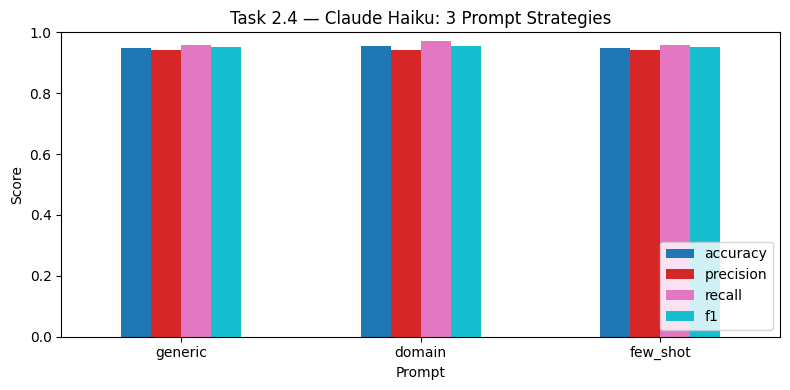

In [6]:
import matplotlib.pyplot as plt
from IPython.display import display

comp = pd.DataFrame([
    {'Prompt': k, **v} for k, v in prompt_results.items()
])
display(comp.set_index('Prompt'))

ax = comp.set_index('Prompt')[['accuracy', 'precision', 'recall', 'f1']].plot(
    kind='bar', figsize=(8, 4), rot=0, colormap='tab10')
ax.set_ylim(0, 1)
ax.set_title(f'Task 2.4 — Claude Haiku: 3 Prompt Strategies')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../results/fig_llm_prompting.png', dpi=150, bbox_inches='tight')
plt.show()